# Differentialgleichungen III: Lineare Systeme und Phasenportraits

Begleitendes Notebook zu *Angew.Mathe.1Differentialgleichungen_S28-37*: Zustandsraumdarstellung, Eigenwertmethode, Fundamentalmatrix, Stabilität und inhomogene Systeme.

**Voraussetzungen:** `numpy`, `sympy`, `matplotlib`  
**Arbeitsweise:** Zellen der Reihe nach ausführen und die Kontrollausgaben prüfen.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/karkessler/dhbw-mathe3/blob/main/notebooks/differentialgleichungen/03_dgl_systeme_phasenportrait.ipynb)

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing()
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True

## 1. Höhere DGL als System erster Ordnung

Eine Differentialgleichung höherer Ordnung kann als System erster Ordnung geschrieben werden. Dazu werden die Funktion und ihre erste Ableitung als Zustandsgrößen definiert: $z_1=y$ und $z_2=y'$. Dann gilt $z_1'=z_2$ und aus der Ausgangsgleichung folgt $z_2'=-2z_1-3z_2$.

Beide Gleichungen zusammen haben die kompakte Form $z'=Az$ mit $A=\begin{pmatrix}0&1\\-2&-3\end{pmatrix}$. Die Matrix beschreibt, wie sich der gesamte Zustand $(y,y')$ lokal ändert. Die Codezelle bestimmt ihre Eigenwerte und Eigenvektoren; negative Realteile der Eigenwerte bedeuten, dass der Ursprung asymptotisch stabil ist.

In [2]:
A = np.array([[0.0, 1.0], [-2.0, -3.0]])
vals, vecs = np.linalg.eig(A)
print('A =\n', A)
print('Eigenwerte:', vals)
print('Eigenvektoren (Spalten):\n', vecs)
print('Asymptotisch stabil:', np.all(np.real(vals) < 0))

A =
 [[ 0.  1.]
 [-2. -3.]]
Eigenwerte: [-1. -2.]
Eigenvektoren (Spalten):
 [[ 0.70710678 -0.4472136 ]
 [-0.70710678  0.89442719]]
Asymptotisch stabil: True


## 2. Exakte Lösung mit Eigenwertzerlegung

Für ein lineares System mit konstanten Koeffizienten zerlegt die Eigenwertzerlegung den Anfangszustand in Eigenrichtungen. Entlang eines Eigenvektors wird der zugehörige Anteil nur mit $e^{\lambda t}$ skaliert. Sind die Eigenwerte verschieden, lautet die Lösung daher als Summe dieser Exponentialanteile.

Die Funktion `solution_constant_system` berechnet zunächst Eigenwerte und die Eigenvektormatrix $V$, bestimmt aus $V c=z(0)$ die Gewichte $c$ der Eigenrichtungen und setzt anschließend $z(t)=V\operatorname{diag}(e^{\lambda_1t},e^{\lambda_2t})c$ zusammen. Der Plot zeigt die beiden Zustandskomponenten $y(t)$ und $y'(t)$ für eine konkrete Anfangsbedingung.

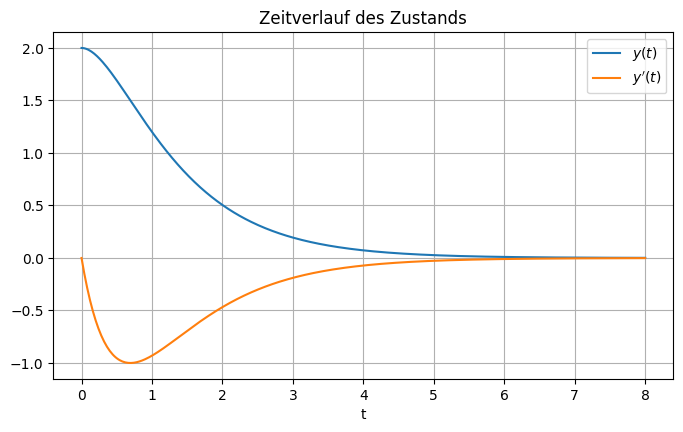

In [3]:
def solution_constant_system(A, z0, times):
    vals, V = np.linalg.eig(A)
    coeff = np.linalg.solve(V, z0)
    return np.array([V @ (np.exp(vals*t) * coeff) for t in times]).real

t = np.linspace(0, 8, 400)
z0 = np.array([2.0, 0.0])
z = solution_constant_system(A, z0, t)
plt.plot(t, z[:,0], label='$y(t)$')
plt.plot(t, z[:,1], label="$y'(t)$")
plt.xlabel('t'); plt.legend(); plt.title('Zeitverlauf des Zustands'); plt.show()

### 2.1 Wronski-Determinante und Formel von Liouville

Für $y''+3y'+2y=0$ bilden $y_1=e^{-t}$ und $y_2=e^{-2t}$ die Fundamentalmatrix $\Phi(t)=\begin{pmatrix}y_1&y_2\\y_1'&y_2'\end{pmatrix}$. Ihre Determinante ist die Wronski-Determinante $W(t)$ (Skript Satz 1.7.1). Nach Liouville gilt
$$W(t)=W(0)\,e^{\operatorname{spur}(A)\,t},\qquad \operatorname{spur}(A)=-a=-3.$$
$W(t)$ ist die Fläche des Parallelogramms aus den Spalten von $\Phi(t)$. Sie schrumpft, wird aber nie null: Die Lösungen bleiben linear unabhängig.

W(t) = -exp(-3*t)    spur(A) = -3


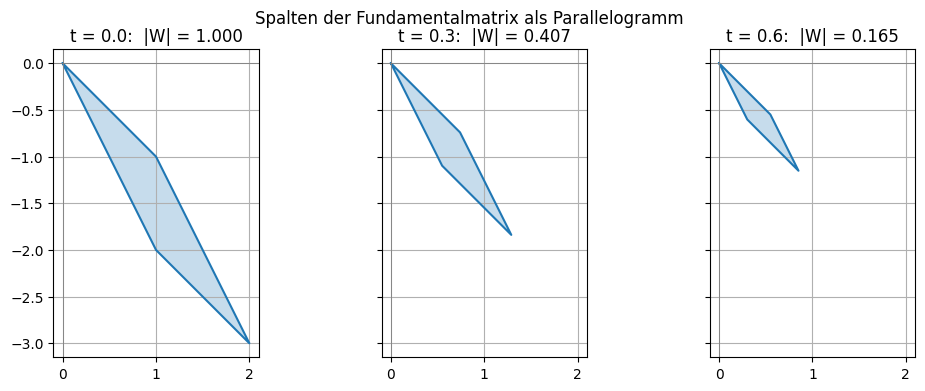

In [4]:
t_s = sp.symbols('t', real=True)
y1, y2 = sp.exp(-t_s), sp.exp(-2*t_s)
Phi = sp.Matrix([[y1, y2], [sp.diff(y1, t_s), sp.diff(y2, t_s)]])
W = sp.simplify(Phi.det())
A_s = sp.Matrix(A.astype(int))
print('W(t) =', W, '   spur(A) =', A_s.trace())
assert sp.simplify(W - W.subs(t_s, 0)*sp.exp(A_s.trace()*t_s)) == 0

Phi_num = sp.lambdify(t_s, Phi, 'numpy')
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
for ax, tv in zip(axs, (0.0, 0.3, 0.6)):
    M = np.array(Phi_num(tv), dtype=float)
    P = np.array([[0, 0], M[:, 0], M[:, 0] + M[:, 1], M[:, 1], [0, 0]])
    ax.fill(P[:, 0], P[:, 1], alpha=0.25); ax.plot(P[:, 0], P[:, 1])
    ax.set_title(f't = {tv}:  |W| = {abs(np.linalg.det(M)):.3f}'); ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
plt.suptitle('Spalten der Fundamentalmatrix als Parallelogramm'); plt.show()

## 3. Phasenportrait

Ein Phasenportrait zeichnet nicht die Zeit auf einer Achse, sondern den Zustand direkt als Punkt $(z_1,z_2)=(y,y')$. Die Pfeile des Vektorfelds zeigen für jeden Zustand die lokale Änderungsrichtung $Az$. Eine Lösungskurve entsteht, indem sie diesem Feld mit wachsender Zeit folgt.

Die gezeichneten Trajektorien starten mit unterschiedlichen Anfangswerten. Sie laufen alle zum Ursprung, weil beide Eigenwerte der Systemmatrix negativ sind. Die Form eines stabilen Knotens entsteht, weil die beiden reellen Eigenrichtungen unterschiedlich schnell abklingen; langfristig ist die Richtung zum langsameren Eigenwert sichtbar.

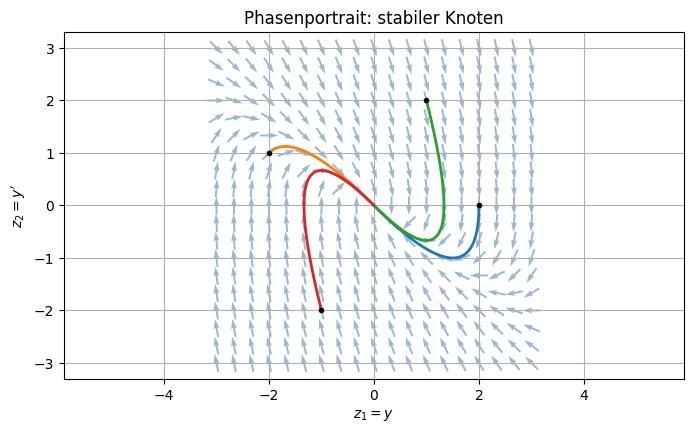

In [5]:
g = np.linspace(-3, 3, 19)
X, Y = np.meshgrid(g, g)
U = A[0,0]*X + A[0,1]*Y
Vv = A[1,0]*X + A[1,1]*Y
N = np.sqrt(U**2 + Vv**2); N[N == 0] = 1
plt.quiver(X, Y, U/N, Vv/N, color='#9bb7d4', pivot='mid')
for z0 in ([2,0], [-2,1], [1,2], [-1,-2]):
    tr = solution_constant_system(A, np.array(z0, dtype=float), t)
    plt.plot(tr[:,0], tr[:,1], linewidth=2)
    plt.plot(*z0, 'o', color='black', markersize=3)
plt.xlabel('$z_1=y$'); plt.ylabel("$z_2=y'$");
plt.title('Phasenportrait: stabiler Knoten'); plt.axis('equal'); plt.show()

## 4. Inhomogenes diagonales System

Bei einem inhomogenen System $z'=Dz+b(t)$ wirkt der Term $b(t)$ als äußere Anregung. Weil $D=\operatorname{diag}(-1,-2)$ diagonal ist, entkoppeln die beiden Gleichungen: $z_1'=-z_1+1$ und $z_2'=-2z_2+t$. Sie können daher getrennt gelöst werden.

Die erste Komponente nähert sich wegen der konstanten Anregung dem Wert $1$. Die zweite Komponente folgt langfristig ungefähr der linearen Funktion $t/2-1/4$, weil die Anregung selbst wächst. Die Codezelle bildet für beide Komponenten das Residuum und prüft zusätzlich die Anfangswerte; beides muss null ergeben.

In [6]:
t_sym = sp.symbols('t', nonnegative=True)
z1 = 1 - sp.exp(-t_sym)
z2 = t_sym/sp.Integer(2) - sp.Rational(1,4) + sp.exp(-2*t_sym)/4
check1 = sp.simplify(sp.diff(z1,t_sym) - (-z1 + 1))
check2 = sp.simplify(sp.diff(z2,t_sym) - (-2*z2 + t_sym))
print('Residuen:', check1, check2)
print('Anfangswerte:', z1.subs(t_sym,0), z2.subs(t_sym,0))
assert check1 == check2 == 0

Residuen: 0 0
Anfangswerte: 0 0


## 5. Stabilität verschiedener Matrizen

Die Realteile der Eigenwerte klassifizieren das lokale Verhalten eines linearen Systems $z'=Az$. Sind alle Realteile negativ, ist der Ursprung asymptotisch stabil; ist mindestens einer positiv, existiert eine instabile Richtung. Komplexe Eigenwerte erzeugen zusätzlich eine Drehbewegung und damit spiralförmige Bahnen.

Die Beispiele zeigen vier typische Fälle: Ein stabiler Knoten besitzt zwei negative reelle Eigenwerte, ein Sattel einen positiven und einen negativen Eigenwert, ein stabiler Fokus komplexe Eigenwerte mit negativem Realteil und ein Zentrum rein imaginäre Eigenwerte. Die ausgegebenen Eigenwerte liefern damit direkt die qualitative Klassifikation.

In [7]:
matrices = {
    'stabiler Knoten': np.array([[-1.,0.],[0.,-2.]]),
    'Sattel': np.array([[1.,0.],[0.,-2.]]),
    'stabiler Fokus': np.array([[-0.3,-1.],[1.,-0.3]]),
    'Zentrum': np.array([[0.,-1.],[1.,0.]]),
}
for name, matrix in matrices.items():
    eig = np.linalg.eigvals(matrix)
    print(f'{name:16s}: Eigenwerte {eig}')

stabiler Knoten : Eigenwerte [-1. -2.]
Sattel          : Eigenwerte [ 1. -2.]
stabiler Fokus  : Eigenwerte [-0.3+1.j -0.3-1.j]
Zentrum         : Eigenwerte [0.+1.j 0.-1.j]
